In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
from IPython.display import HTML

The visualization I chose to recreate for this assignment is "Some EU States Are Recovering Almost All Plastic Packaging", which was presented by Beautiful News. ([source](https://informationisbeautiful.net/beautifulnews/452-europe-plastic-recovery/))

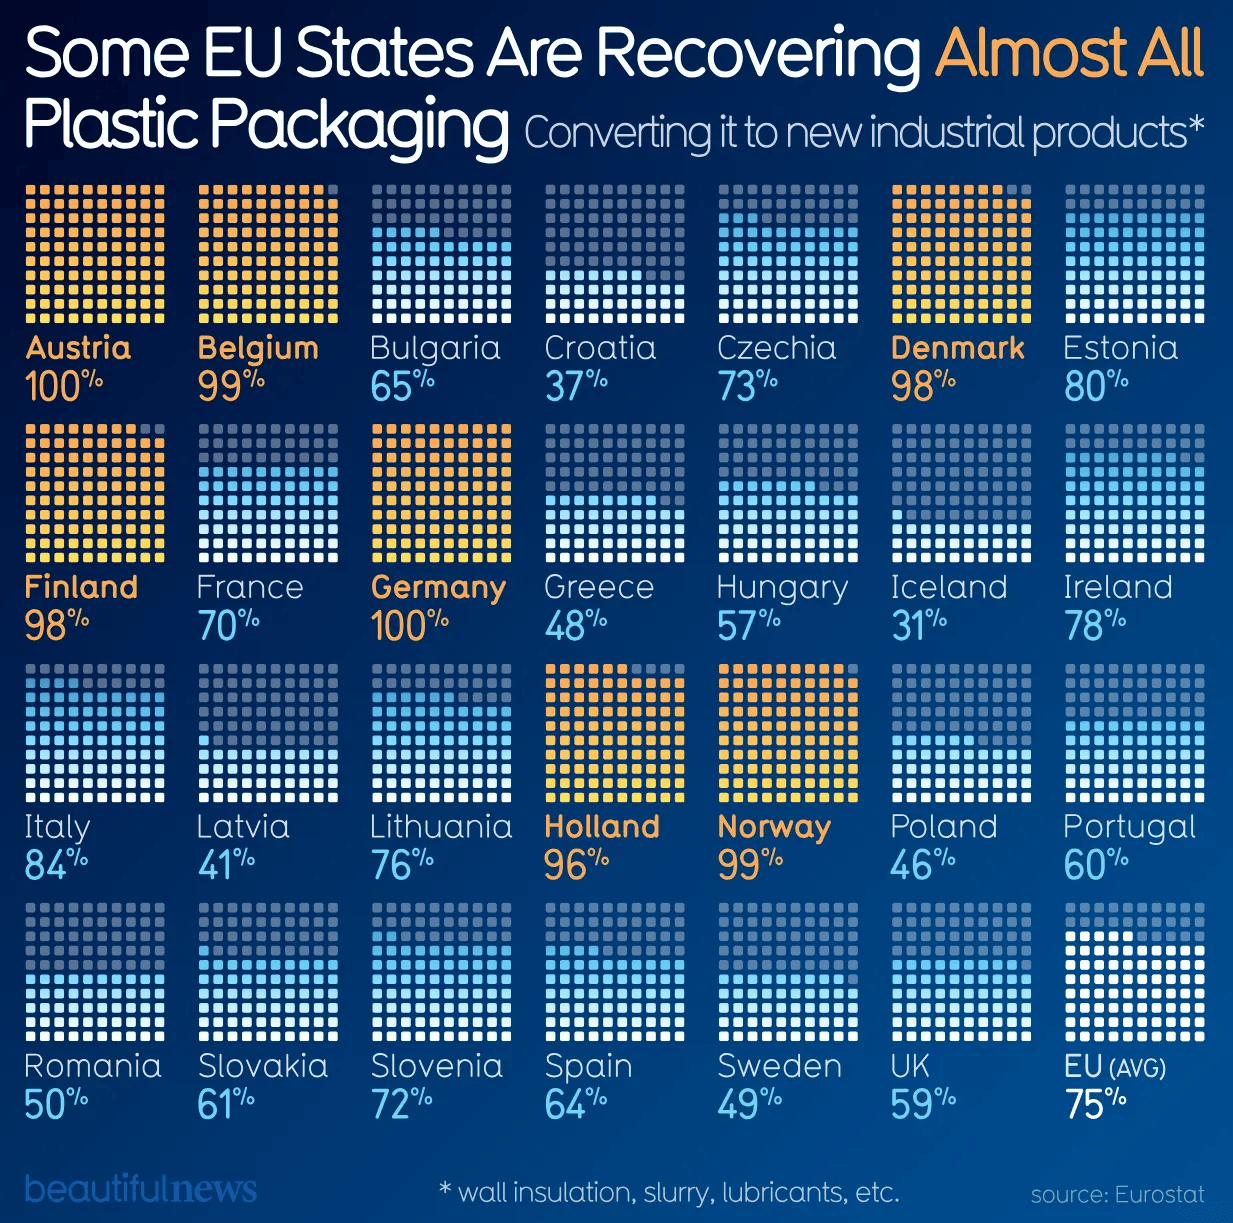

The original data this visualization was made from is given [here](https://docs.google.com/spreadsheets/d/1G27tUXk_-MOQYRRYL2lZeRvKAboaVnK_va-xfCqBvXs/edit?usp=sharing).

In [ ]:
# Loading the data from the google sheet:
sheet_name = 'Some EU Countries Recover Almost All Plastic Packaging'
sheet_id = '1G27tUXk_-MOQYRRYL2lZeRvKAboaVnK_va-xfCqBvXs'
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
url = url.replace(" ", "%20")
data = pd.read_csv(url)

In [ ]:
# Display the original data if you wish!
data

The original dataset is very small with only 38 rows, so I felt comfortable cleaning it up by hand. Changes made include:


*   Getting rid of the last two columns (source and URL). They are not important for the visualisation.
*   Removing all countries/territories that do not appear in the final vis (e.g. Albania, Cyprus, Montenegro, etc.).
*  Rounding the plastic recovery rates, which are expressed as percentages, to the nearest integer.
*  Removing asterisks from the ends of certain country names (e.g. Italy).
*  Removing the parenthetical after Germany.
*  Renaming the Netherlands to Holland, and shortening "European Union" and "United Kingdom" to "EU (AVG)" and "UK" respectively.
*  Reordering the rows by country name to match their order in the vis.

I saved the resulting csv file as "data.csv". The contents of the file are given below:

```
country,recovery rate
Austria,100
Belgium,99
Bulgaria,65
Croatia,37
Czechia,73
Denmark,98
Estonia,80
Finland,98
France,70
Germany,100
Greece,48
Hungary,57
Iceland,31
Ireland,78
Italy,84
Latvia,41
Lithuania,76
Holland,96
Norway,99
Poland,46
Portugal,60
Romania,50
Slovakia,60
Slovenia,72
Spain,64
Sweden,49
UK,59
EU (AVG),75
```

The target vis is identified as a dot matrix chart. A google search shows that a person named Amit Kapoor made some basic code in [Vega-Lite](https://vega.github.io/vega-lite/) to create this sort of chart. His work is publicly available [on his GitHub](https://gist.github.com/amitkaps/67bd6dcb2af300a2b76f1e2351c1afdc).

Below is Kapoor's code-- edited to use only a small portion of the dataset *gapminder.csv*, also on his GitHub-- and the resulting visualization.



```
{
  "$schema": "https://vega.github.io/schema/vega-lite/v2.json",
  "description": "A Unit Chart with Small Multiples",
  "data": {
    "values": [
      {"id":1,"subid":1,"country":"Algeria","continent":"Africa", "year":2007, "lifeExp":72.301, "pop":33333216, "gdpPercap":6223.367465},
      {"id":2,"subid":2,"country":"Angola","continent":"Africa", "year":2007, "lifeExp":42.731, "pop":12420476, "gdpPercap":4797.231267},
      {"id":3,"subid":3,"country":"Benin","continent":"Africa", "year":2007, "lifeExp":56.728, "pop":8078314, "gdpPercap":1441.284873},
      {"id":4,"subid":4,"country":"Botswana","continent":"Africa", "year":2007, "lifeExp":50.728, "pop":1639131, "gdpPercap":12569.85177},
      {"id":5,"subid":5,"country":"Burkina Faso","continent":"Africa", "year":2007, "lifeExp":52.295, "pop":14326203, "gdpPercap":1217.032994},
      {"id":6,"subid":6,"country":"Burundi","continent":"Africa", "year":2007, "lifeExp":49.58, "pop":8390505, "gdpPercap":430.0706916},
      {"id":7,"subid":7,"country":"Cameroon","continent":"Africa", "year":2007, "lifeExp":50.43, "pop":17696293, "gdpPercap":2042.09524},
      {"id":8,"subid":8,"country":"Central African Republic", "continent":"Africa", "year":2007, "lifeExp":44.741, "pop":4369038, "gdpPercap":706.016537},
      {"id":9,"subid":9,"country":"Chad","continent":"Africa", "year":2007, "lifeExp":50.651, "pop":10238807, "gdpPercap":1704.063724},
      {"id":10,"subid":10,"country":"Comoros","continent":"Africa", "year":2007, "lifeExp":65.152, "pop":710960, "gdpPercap": 	986.1478792},

      {"id":141,"subid":1,"country":"Australia","continent":"Oceania", "year":2007, "lifeExp":81.235, "pop":20434176, "gdpPercap":34435.36744},
      {"id":142,"subid":2,"country":"New Zealand","continent":"Oceania", "year":2007, "lifeExp":80.204, "pop":4115771, "gdpPercap":25185.00911}
    ]
  },
  "mark": "rect",
  "transform": [
    {"calculate": "ceil(datum.subid/ 7)", "as": "Y"},
    {"calculate": "datum.subid - (datum.Y - 1) * 7", "as": "X"}
  ],
  "encoding": {
    "x": {
      "field": "X",
      "type": "ordinal",
      "axis": null
    },
    "y":{
      "field": "Y",
      "type": "ordinal",
      "axis": null
    },
    "color":{
      "field": "continent",
      "type": "nominal"
    },
    "column": {
      "field": "continent",
      "type": "nominal"
    },
    "tooltip":{
      "field": "country",
      "type": "nominal"
    }
  }
}
```



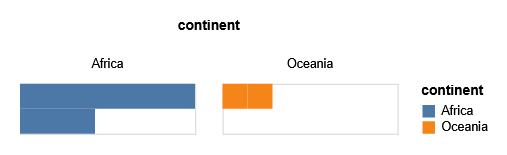


It is immediately obvious from the output that this code is simply creating one rectangle for every data item, and grouping it based on the value of it's "continent" attribute. The position of the rectangle is calculated using the "subid" attribute, while the "id" attribute is not used for anything. Most of the attributes from gapminder.csv are superfluous; the following code generates the exact same image*:
```
{
  "$schema": "https://vega.github.io/schema/vega-lite/v2.json",
  "description": "A Unit Chart with Small Multiples",
  "data": {
    "values": [
      {"id":1,"continent":"Africa"},
      {"id":2,"continent":"Africa"},
      {"id":3,"continent":"Africa"},
      {"id":4,"continent":"Africa"},
      {"id":5,"continent":"Africa"},
      {"id":6,"continent":"Africa"},
      {"id":7,"continent":"Africa"},
      {"id":8, "continent":"Africa"},
      {"id":9, "continent":"Africa"},
      {"id":10, "continent":"Africa"},

      {"id":1, "continent":"Oceania"},
      {"id":2, "continent":"Oceania"}
    ]
  },
  "mark": "rect",
  "transform": [
    {"calculate": "ceil(datum.id/ 7)", "as": "Y"},
    {"calculate": "datum.id - (datum.Y - 1) * 7", "as": "X"}
  ],
  "encoding": {
    "x": {
      "field": "X",
      "type": "ordinal",
      "axis": null
    },
    "y":{
      "field": "Y",
      "type": "ordinal",
      "axis": null
    },
    "color":{
      "field": "continent",
      "type": "nominal"
    },
    "column": {
      "field": "continent",
      "type": "nominal"
    },
    "tooltip":{
      "field": "country",
      "type": "nominal"
    }
  }
}
```

*The same static image; tool tips will cease to provide individual country names, as that attribute no longer exists.

One can already imagine exchanging "continent" with "country" to fit the data of the target visualization.

To achieve the look of the target vis, we note several features that differ from the output above:

* There should not be a legend nor tooltips.
* Each country's grid should be 10x10.
* The countries themselves should be arranged in four rows of seven grids.
* There should not be a pale outline around each grid.
* The rectangle marks should have a slight gap between them, and their corners should be rounded.
* Countries should not have randomly colored grids; the color should be orange if their recovery rate is very high (say >= 90%) and blue otherwise (with an exception for the EU AVG, which has white rectangles). If a grid is orange or blue, each row of the grid should be a slightly different color to create a gradient from light to dark.
* The background should be a diagonal gradient from dark blue in the top right to medium blue in the bottom left.
* Each country's label should be blue/orange/white to match the grid. The title of the vis should be written in white, except for the words "Almost All" which should be orange. All other text should be white.

Not all of the properties outlined above can be implemented in Vega-Lite (or at least, not without significant effort). Starting from the top:

* There should not be a legend nor tooltips.

Delete the entire "tooltip" property.
```
//Remove this!
"tooltip":{
  "field": "country",
  "type": "nominal"
}
```

Add the code `"legend":null` as a property of color, which is itself a property of the encoding. That is to say, the code should look like this:
```
{
...
  "encoding": {
    ...
    "color":{
      ...
      "legend":null
    }
  ...
  }
...
}
```

* Each country's grid should be 10x10.

Under the transform property, replace the sevens with tens:
```
"transform": [
    {"calculate": "ceil(datum.id/ 10)", "as": "Y"},
    {"calculate": "datum.id - (datum.Y - 1) * 10", "as": "X"}
  ],
```

* The countries themselves should be arranged in four rows of seven grids.

Vega-Lite can achieve this using the [facet property](https://vega.github.io/vega-lite/docs/facet.html). The facet operator has two parts:

1. A definition. Which attributes define the axes (rows and/or columns)?
2. A specification. Which marks are being faceted, and how are they visually encoded?

Our current data only has two attributes: "id" and "country".
We need to create two extra attributes to encode position in the 4x7 grid. Call them "r" (for row) and "c" (for column). The marks being faceted are the rectangles in a grid, with modifications via the "transform" and "encoding" properties. The faceting code will look like this:
```
{
...
  "facet": {
    "row": { "field":"r" },
    "column": { "field":"c"}
  },
  "spec":{
    "mark": "rect",
    "transform": ...
    "encoding": ...
  }
...
}
```

You will notice that faceting adds labels of the rows and columns to the vis, which we want to get rid of. To hide them, set `"title:null"` and `"header":{"labels":null}` under both "facet" -> "row" and "facet" -> "column", and add `"title":null` under "spec" -> "encoding" -> "column".
```
{
  ...
  "facet": {
    "row": { "field":"r", "title":null,
              "header": { "labels":null }
           },
    "column": { "field":"c", "title":null,
                "header": { "labels":null }
              }
  },
  "spec":{
    ...
    "encoding": {
      ...
      "column": {
        ...
        "title":null
      }
      ...
    }
    ...
  }
  ...
}
```

* There should not be a pale outline around each grid.

Add the following code:
```
{
  ...
  "config": {
    "style": {
      "cell": {
        "stroke": "transparent"
      }
    }
  },
  ...
}
```

* The rectangle marks should have a slight gap between them, and their corners should be rounded.

We can add gaps between each rectangle by making them smaller. The "mark" property is currently defined by it's type ("rect"), but now we also define the "width" and "height". I chose to set both to 15. To round the corners of the rectangles, also define the "cornerRadius" property. I set it to 5.
```
{
  ...
  "spec":{
    "mark": {"type":"rect", "width":15, "height":15, "cornerRadius":5},
    ...
  },
  ...
}
```

* Countries should not have randomly colored grids; the color should be orange if their recovery rate is very high (say >= 90%) and blue otherwise (with an exception for the EU AVG, which has white rectangles). If a grid is orange or blue, each row of the grid should be a slightly different color to create a gradient from light to dark.

A mark's color can be determined by an attribute. Currently, the data has four attributes: id, country, r, and c. We may create a new attribute called "color" to handle this new task. Vega-Lite has a [tutorial](https://vega.github.io/vega-lite/tutorials/explore.html) which includes defining a color scale. There are two parts to this:

1. A domain. The possible values of the attribute "color".
2. A range. The actual hexadecimal values of the colors we want to use.

The domain must have 21 different values because a rectangle may be gray, one of 9 shades of blue, one of 10 shades of orange, or white. I defined the domain as

\["g", "b1", "b2", "b3", "b4", "b5", "b6", "b7", "b8", "b9", "o1", "o2", "o3", "o4", "o5", "o6", "o7", "o8", "o9", "o10", "w"\].

The range is the corresponding list of hexadecimal values colorpicked from the visualization. Note, b1 is the lightest shade of blue, and b9 is the darkest shade; the orange shades follow the same rule. The code will now look like this:
```
{
  ...
  "spec":{
    ...
    "encoding": {
      ...
      "color":{
        "field": "color",
        "scale": {
          "domain":["g", "b1", "b2", "b3", "b4", "b5", "b6", "b7", "b8", "b9", "o1", "o2", "o3", "o4", "o5", "o6", "o7", "o8", "o9", "o10", "w"],
          "range": ["#597DA7", "#F4FFF9", "#E4F9F4", "#C5EFF9", "#A5E6FE", "#83DDFC", "#64CEF5", "#55BDE7", "#50A9DA", "#4198C9", "#FAE152", "#FED651", "#FFCE55", "#FFC954", "#FFC14B", "#FFB457", "#FFB548", "#FBB14B", "#FBB04D", "#FFA754", "#FFFFFF"]
          ...
        }
        ...
      }
      ...
    }
    ...
  }
  ...
}
```

Another consideration with color is that it is easier to specify rectangles from right to left rather than from left to right. That way all of the gray rectangles can be added before the blue/orange/white ones. To reverse the order in which rectangles are drawn, just multiply the calculation of "X" by -1.
```
{
  ...
  "spec":{
    ...
    "transform": [
      ...
      {"calculate": "-1 * (datum.id - (datum.Y - 1) * 10)", "as": "X"}
    ],
    ...
  }
  ...
}
```


* The background should be a diagonal gradient from dark blue in the top right to medium blue in the bottom left.

Unfortunately Vega-Lite only allows solid color backgrounds. It is possible to color areas with a gradient, and theoretically and background filling area with a graident could be layered with the main chart, but this seemed overly convoluted. I set the background to an mid-range blue, colorpicked from the vis, and did not pursue the topic further.

```
{
  ...
  "background":"#001E4F",
  ...
}
```

* Each country's label should be blue/orange/white to match the grid. The title of the vis should be written in white, except for the words "Almost All" which should be orange. All other text should be white.

It is possible to choose colors based on a defined [condition](https://vega.github.io/vega-lite/docs/condition.html), but in my testing it seemed like a binary choice. Two colors is not enough for this vis since country labels can be blue, orange, or white (if it's the EU AVG in the last case).

In Vega-Lite strings are also limited to only have one size and color, so the only way to non-uniformly stylize text is to have multiple layers in the vis, each with a string that can be individually styled and positioned near the others. However, this function appears to break if faceting is involved on one of the layers. The only text I could keep were titles, subtitles, and labels, which I made all white. The formatting I used is given below:
```
{
  ...
  "padding": {"top": 20, "bottom": 20, "left": 30, "right": 30},
  "title":{
    "text":["Some EU States are Recovering Almost All", "Plastic Packaging: Converting it to new industrial products*"],
    "align":"left",
    "anchor":"start",
    "baseline":"line-top",
    "fontSize":55,
    "color":"white",
	  "font":"nunito light"
  },
  ...
  "spec":{
    ...
    "encoding": {
      ...
      "column": {
        ...
        "header": {
          "labelFontSize": 30,
          "labelFont":"nunito light",
          "labelColor":"white",
          "orient":"bottom"
		    }
      }
    }
  }
  ...
}
```

The last part of creating the visualization, which I handwaved in the section above, is how to produce data for Vega-Lite when the vis requires 2,800 rectangles-- far too many to create by hand.

According to Vega-Lite's documentation, it is possible to read data from a csv file via a url, but I encountered a network error when attempting to do so. To avoid this, I wrote a script in C++ which reads *data.csv* and outputs *formatted_data.txt*, an inline dataset for Vega-Lite which can be copy-pasted into the code. My code is given below.



```
/****
 * Author: Laboni Goswami
 * Email: labonig1@umbc.edu
 * Description: This program reads data.csv and outputs a txt file with data formatted for vega-lite
 ****/

#include <iostream>
#include <fstream>
#include <string>
#include <vector>
#include <cmath>
using namespace std;

const int NUM_COUNTRIES = 28;
const int COUNTRIES_PER_ROW = 7;

int main(int argc, char** argv){
    const string ifilename = "data.csv";
    const string ofilename = "formatted_data.txt";
    ifstream input(ifilename);
    ofstream output;
    string country, str_recovery_rate, trash;
    vector<pair<string,int>> country_rate;
    int numgray;

    //check if the input file opened successfully
    if(!input.is_open()){
        cerr << "Error: could not open " << ifilename << "\n";
        return 0;
    }

    // ignore the first line of the csv file
    getline(input, trash);

    //read the data and store it in the country_rate vector
    while(getline(input, country, ',') &&
          getline(input, str_recovery_rate))
          {
            country_rate.push_back(pair<string,int>(country, stoi(str_recovery_rate)));
          }

    input.close();

    //Check if the output file opens successfully
    output.open(ofilename);
    if(!output.is_open()){
        cerr << "Error: could not open " << ofilename << "\n";
        return 0;
    }
    
    //The output data is formatted for use in Vega-Lite
    // {"id":___, "country": ___, "color":___, "r:"___, "c":___},
    output << "\"data\": {\n"
           << "\t\"values\": [\n";

    //The following loop visually represents each country's percentage of recovered plastic by generating 100 colored squares per country
    //Squares are generated from right to left, top to bottom in a 10x10 grid
    //For coloring, there are four general bins: "g" (gray), "b" (blue), "o" (orange), and "w" (white)
    //Nuances in the shade of blue/orange to use are given by a number n = 1, 2, 3,..., with increasing n being darker/more saturated
    //The placement of a country within the larger vis (a 4x7 grid) is determined by r (row) and c (column)
    for(int id = 1; id <= NUM_COUNTRIES; id++){
        numgray = 100 - country_rate.at(id-1).second;
        for(int subid = 1; subid <= 100; subid++){
            output << "\t\t{\"id\":" << subid << ", \"country\":\"" << country_rate.at(id-1).first << " " << country_rate.at(id-1).second << "%" << "\", \"color\":";
            if(numgray > 0){
                output << "\"g\"";
                numgray--;
            }
            else if(country_rate.at(id-1).first == "EU (AVG)")
                output << "\"w\"";
            else if(country_rate.at(id-1).second < 90)
                output << "\"b" << ceil(double(100 + 1 - subid)/10) << "\"";
            else
                output << "\"o" << ceil(double(100 + 1 - subid)/10) << "\"";

            output << ", \"r\":" << (id-1)/COUNTRIES_PER_ROW + 1
                   << ", \"c\":" << (id-1) % COUNTRIES_PER_ROW + 1;

            output << "}";
            if(id == NUM_COUNTRIES && subid == 100)
                output << "\n";
            else
                output << ",\n";
        }
    }
    output << "\t]\n}";
    
    output.close();

    return 0;
}
```



The final recreation of the vis with a caption:

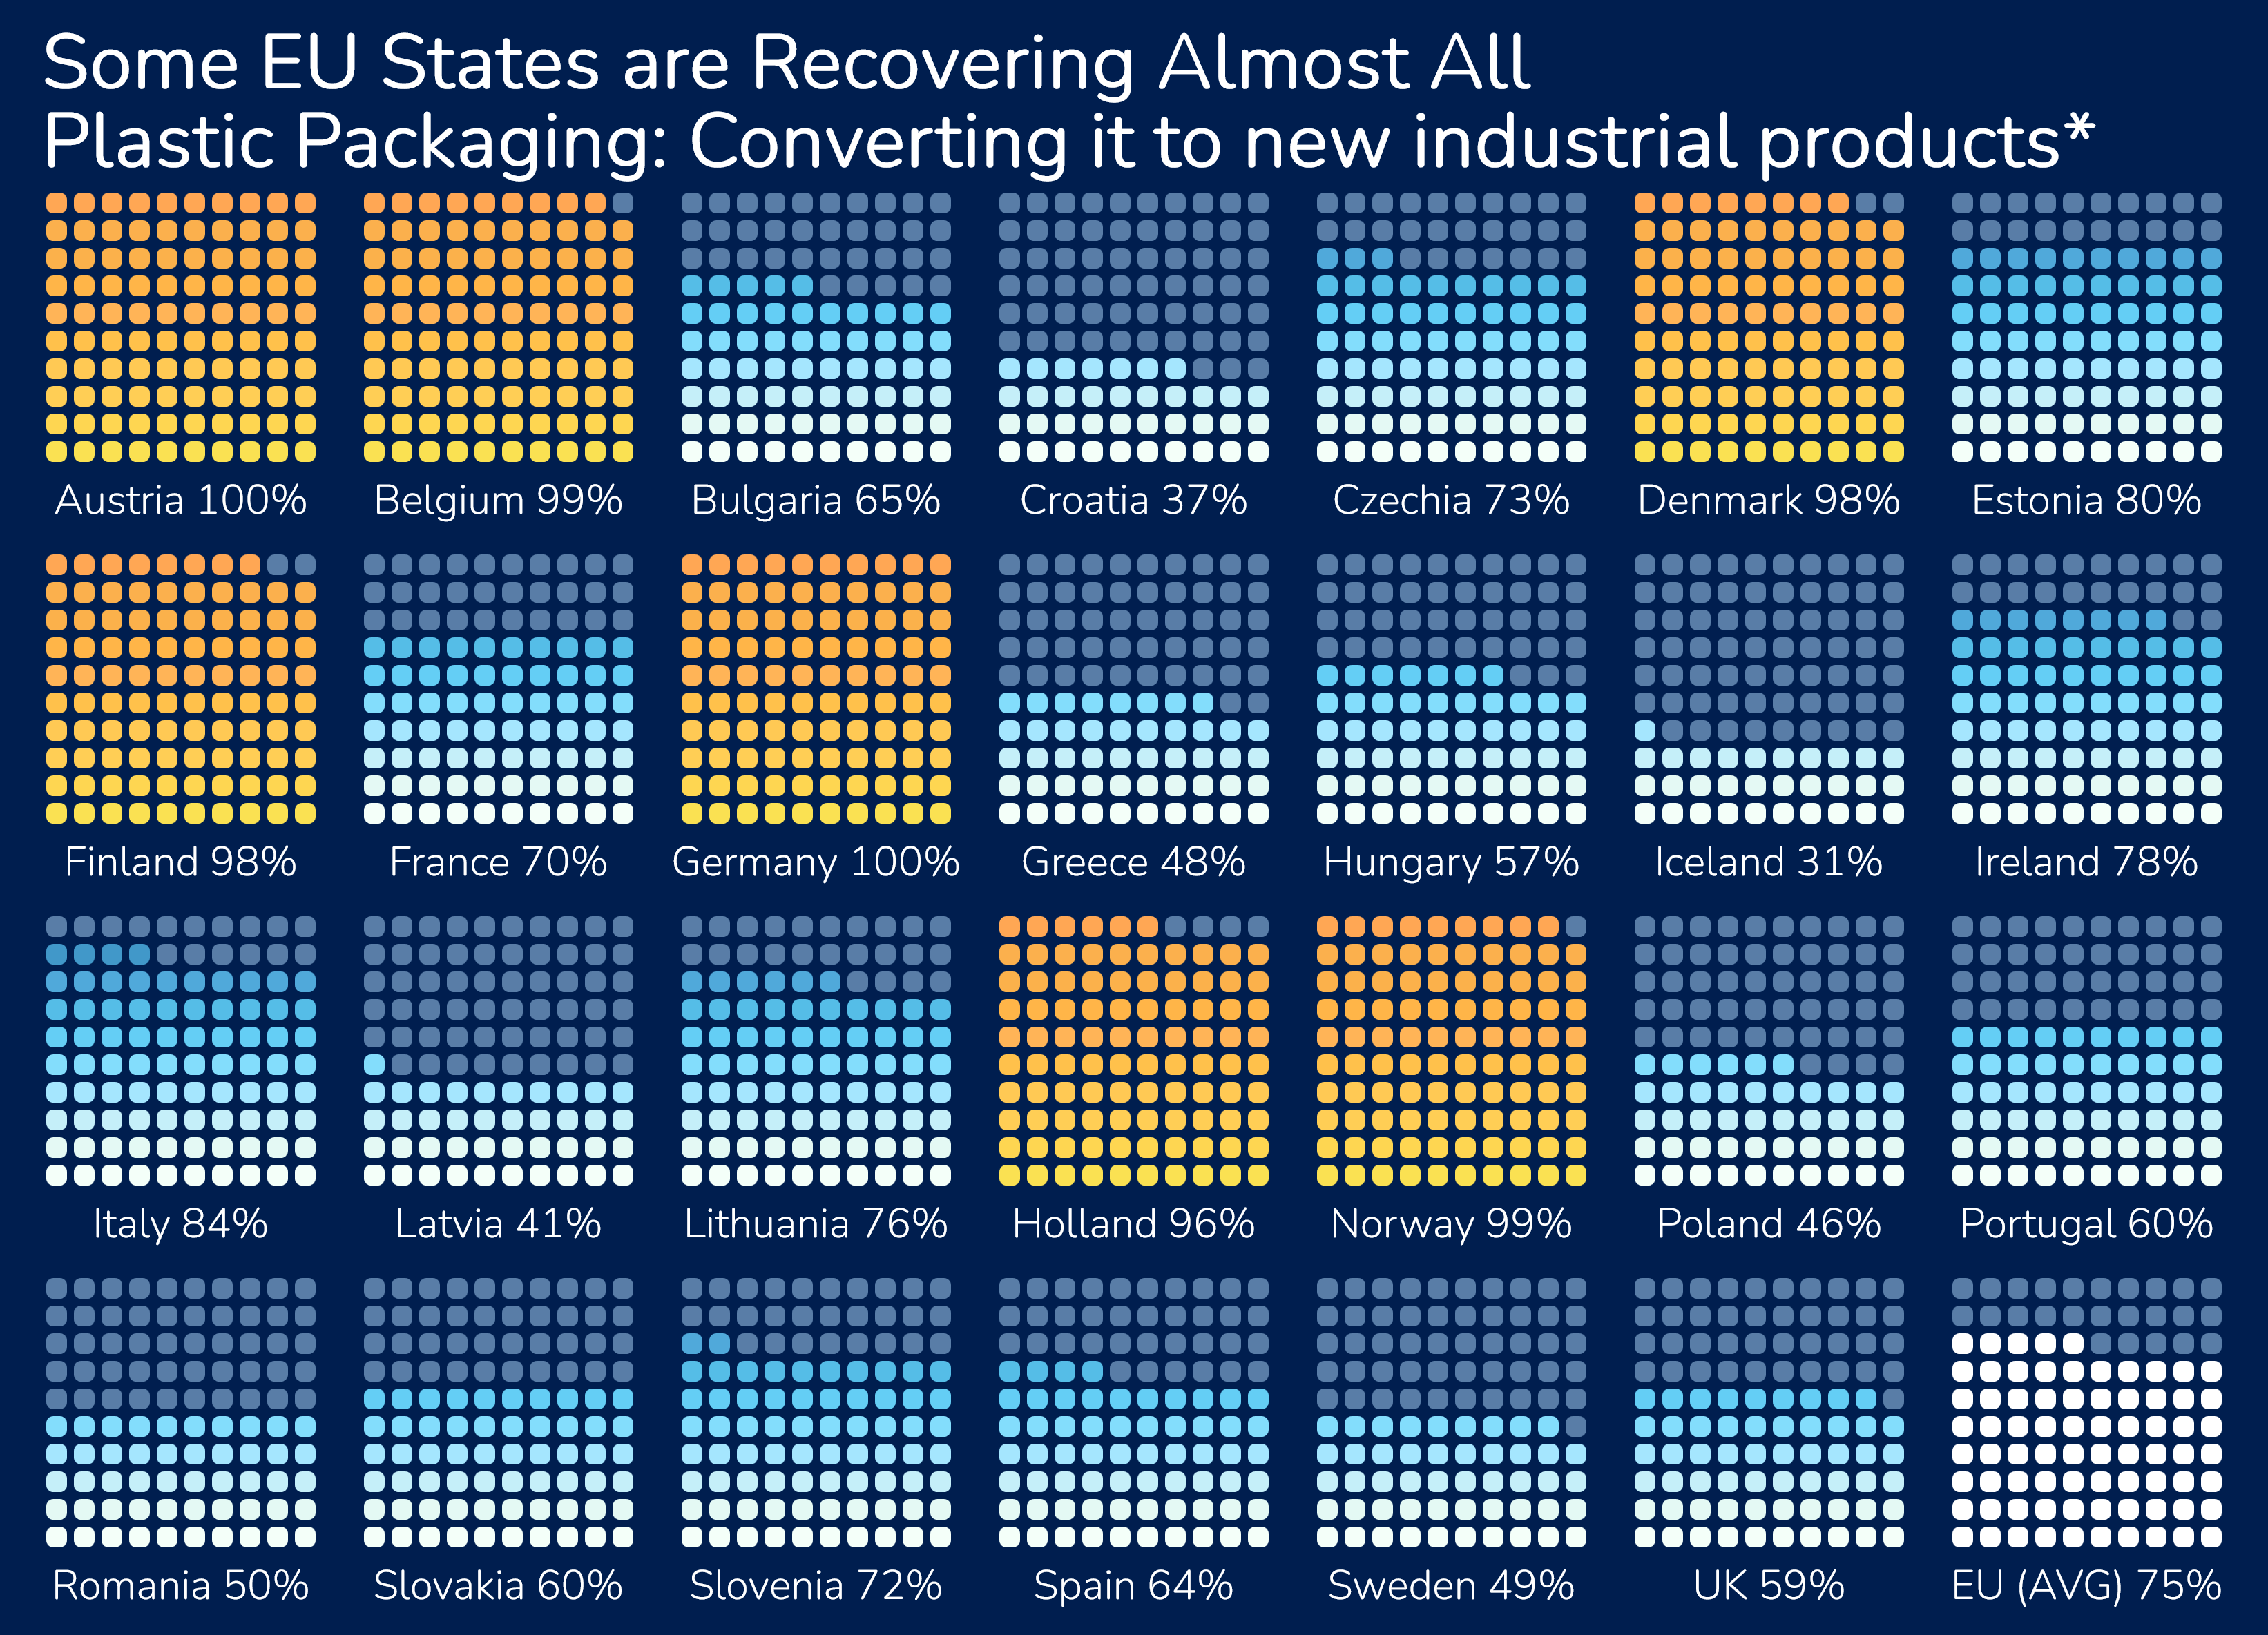

**Fig. 1.** Plastic packaging recovery rates among EU nations. In Europe, most plastic waste is turned into new products  instead of being sent to a landfill. "New products" includes, but is not limited to, wall insulation, slurry, and lubricants. "New products" do not include heat/energy from incineration. This distinction may make Sweden appear less environmentally friendly than it truly is.